<a href="https://colab.research.google.com/github/mowoo-987/PeopleIQ/blob/main/PeopleIQ_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PeopleIQ — AI-Powered HR Analytics
**Built by Myra Owoo | BIS Graduate, Saskatchewan Polytechnic**

GitHub: [github.com/mowoo-987/PeopleIQ](https://github.com/mowoo-987/PeopleIQ)

---

PeopleIQ is an AI-powered HR analytics tool that helps organisations understand their workforce, identify turnover patterns and predict which employees are at risk of leaving — before they do.

**This notebook covers:**
- Workforce overview and department analytics
- Turnover analysis and key drivers
- AI churn prediction using Random Forest
- At-risk employee identification
- Actionable insights and recommendations

## Step 1 — Install and Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
BLUE = '#1F4E79'
LIGHT_BLUE = '#2E75B6'
ACCENT = '#4BACC6'
RED = '#FF6B6B'
GREEN = '#A9D18E'

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Generate Sample HR Dataset

In [18]:
# Import necessary libraries
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Define static data for generating employee profiles
departments = ['Engineering', 'Sales', 'HR', 'Finance', 'Operations', 'Marketing', 'Customer Service', 'IT']
job_titles = {
    'Engineering': ['Software Developer', 'Systems Analyst', 'QA Engineer', 'DevOps Engineer'],
    'Sales': ['Sales Representative', 'Account Manager', 'Sales Coordinator'],
    'HR': ['HR Coordinator', 'Recruiter', 'HR Analyst'],
    'Finance': ['Financial Analyst', 'Accountant', 'Budget Analyst'],
    'Operations': ['Operations Analyst', 'Process Coordinator', 'Operations Manager'],
    'Marketing': ['Marketing Coordinator', 'Content Analyst', 'Digital Marketer'],
    'Customer Service': ['Customer Service Rep', 'Support Analyst', 'Team Lead'],
    'IT': ['IT Support Specialist', 'Business Analyst', 'Data Analyst']
}
education = ['High School', 'Diploma', 'Bachelor', 'Master']
genders = ['Male', 'Female', 'Non-Binary']

# Number of employees to generate
n = 300
data = []

# Loop to generate individual employee data
for i in range(1, n + 1):
    dept = random.choice(departments)
    title = random.choice(job_titles[dept])
    age = random.randint(22, 62)
    tenure = random.randint(0, 15)
    salary = random.randint(40000, 120000)
    satisfaction = random.randint(1, 10)
    performance = random.randint(1, 10)
    absences = random.randint(0, 20)
    overtime = random.choice([0, 1])

    # Calculate a churn score based on various factors
    churn_score = (10 - satisfaction) * 0.3 + absences * 0.05 + (10 - performance) * 0.2 + overtime * 0.1
    # Determine if an employee 'left' based on churn score and a random factor
    left = 1 if churn_score > 2.5 and random.random() > 0.4 else 0

    # Append employee data to the list
    data.append({
        'EmployeeID': f'EMP{i:04d}', 'Age': age, 'Gender': random.choice(genders),
        'Education': random.choice(education), 'Department': dept, 'JobTitle': title,
        'Tenure_Years': tenure, 'Salary': salary, 'JobSatisfaction': satisfaction,
        'PerformanceRating': performance, 'Absences': absences, 'OverTime': overtime,
        'EmploymentStatus': 'Resigned' if left == 1 else 'Active', 'Left': left
    })

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(data)

# Print dataset summary and turnover rate
print(f'Dataset created: {len(df)} employees')
print(f'Turnover rate: {df["Left"].mean():.1%}')

# Display the first few rows of the DataFrame
df.head()

Dataset created: 300 employees
Turnover rate: 34.0%


,EmployeeID,Age,Gender,Education,Department,JobTitle,Tenure_Years,Salary,JobSatisfaction,PerformanceRating,Absences,OverTime,EmploymentStatus,Left
0,EMP0001,39,Male,High School,Sales,Sales Representative,7,69256,3,2,17,0,Resigned,1
1,EMP0002,36,Female,High School,Sales,Sales Representative,0,113563,4,9,13,0,Resigned,1
2,EMP0003,49,Male,Bachelor,HR,HR Analyst,10,76421,3,4,10,0,Active,0
3,EMP0004,38,Non-Binary,Bachelor,Marketing,Digital Marketer,1,100217,9,2,12,0,Active,0
4,EMP0005,34,Female,Bachelor,Marketing,Digital Marketer,2,46006,4,5,2,0,Resigned,1


## Step 3 — Workforce Overview

In [3]:
# Calculate key workforce metrics
total = len(df) # Total number of employees
active = len(df[df['EmploymentStatus'] == 'Active']) # Number of active employees
resigned = len(df[df['Left'] == 1]) # Number of resigned employees
turnover_rate = resigned / total * 100 # Calculate the turnover rate
avg_tenure = df['Tenure_Years'].mean() # Calculate average tenure in years
avg_salary = df['Salary'].mean() # Calculate average salary
avg_satisfaction = df['JobSatisfaction'].mean() # Calculate average job satisfaction

# Print the workforce overview header
print('=' * 50)
print('         PEOPLEIQ — WORKFORCE OVERVIEW')
print('=' * 50)

# Print the calculated workforce statistics
print(f' Total Employees:       {total}')
print(f' Active Employees:      {active}')
print(f' Resigned Employees:    {resigned}')
print(f' Turnover Rate:         {turnover_rate:.1f}%')
print(f' Average Tenure:        {avg_tenure:.1f} years')
print(f' Average Salary:        ${avg_salary:,.0f}')
print(f' Average Satisfaction:  {avg_satisfaction:.1f}/10')

# Print the footer
print('=' * 50)

         PEOPLEIQ — WORKFORCE OVERVIEW
 Total Employees:       300
 Active Employees:      198
 Resigned Employees:    102
 Turnover Rate:         34.0%
 Average Tenure:        7.4 years
 Average Salary:        $81,515
 Average Satisfaction:  5.4/10


## Step 4 — Department Analysis

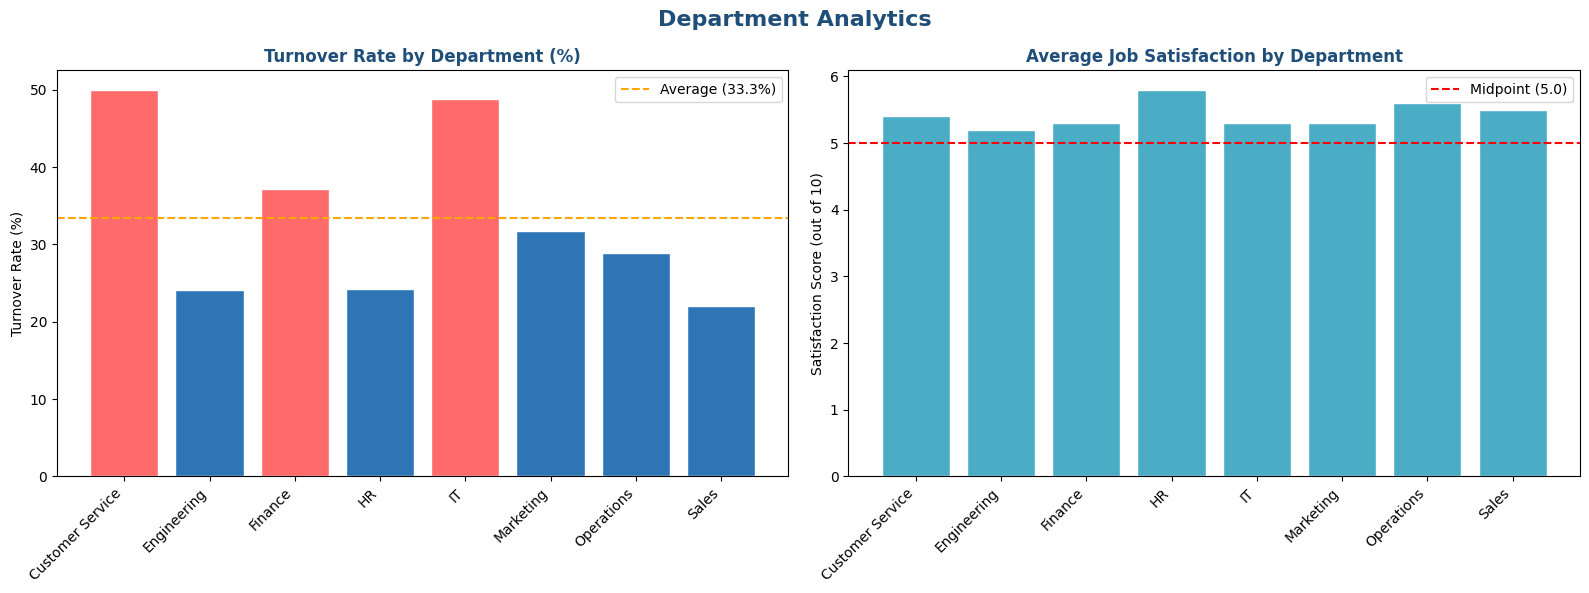


📊 Department Summary:
      Department  Total  Resigned  Turnover_Rate  Avg_Satisfaction  Avg_Salary
Customer Service     40        20           50.0               5.4     82278.0
     Engineering     29         7           24.1               5.2     75245.0
         Finance     35        13           37.1               5.3     80077.0
              HR     33         8           24.2               5.8     81410.0
              IT     43        21           48.8               5.3     79840.0
       Marketing     41        13           31.7               5.3     83798.0
      Operations     38        11           28.9               5.6     81770.0
           Sales     41         9           22.0               5.5     85756.0


In [6]:
# Group data by department to calculate key metrics for each department
dept_stats = df.groupby('Department').agg(
    Total=('EmployeeID', 'count'), # Total number of employees in each department
    Resigned=('Left', 'sum'),      # Number of employees who resigned from each department
    Avg_Satisfaction=('JobSatisfaction', 'mean'), # Average job satisfaction in each department
    Avg_Salary=('Salary', 'mean') # Average salary in each department
).reset_index()

# Calculate turnover rate for each department and round to one decimal place
dept_stats['Turnover_Rate'] = (dept_stats['Resigned'] / dept_stats['Total'] * 100).round(1)
# Round average satisfaction to one decimal place
dept_stats['Avg_Satisfaction'] = dept_stats['Avg_Satisfaction'].round(1)
# Round average salary to zero decimal places
dept_stats['Avg_Salary'] = dept_stats['Avg_Salary'].round(0)

# Create a figure with two subplots for visualising department analytics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Set the main title for the entire figure
fig.suptitle('Department Analytics', fontsize=16, fontweight='bold', color=BLUE)

# --- First Subplot: Turnover by Department ---
# Define colors for the bars: RED if turnover rate is high (>35%), otherwise LIGHT_BLUE
colors = [RED if x > 35 else LIGHT_BLUE for x in dept_stats['Turnover_Rate']]
# Create a bar chart for turnover rate by department
axes[0].bar(dept_stats['Department'], dept_stats['Turnover_Rate'], color=colors, edgecolor='white')
# Set title for the first subplot
axes[0].set_title('Turnover Rate by Department (%)', fontweight='bold', color=BLUE)
# Rotate x-axis labels for better readability
axes[0].set_xticklabels(dept_stats['Department'], rotation=45, ha='right')
# Set y-axis label
axes[0].set_ylabel('Turnover Rate (%)')
# Add a horizontal line indicating the average turnover rate across all departments
axes[0].axhline(y=dept_stats['Turnover_Rate'].mean(), color='orange', linestyle='--', label=f'Average ({dept_stats["Turnover_Rate"].mean():.1f}%)')
# Display legend
axes[0].legend()

# --- Second Subplot: Satisfaction by Department ---
# Create a bar chart for average job satisfaction by department
axes[1].bar(dept_stats['Department'], dept_stats['Avg_Satisfaction'], color=ACCENT, edgecolor='white')
# Set title for the second subplot
axes[1].set_title('Average Job Satisfaction by Department', fontweight='bold', color=BLUE)
# Rotate x-axis labels for better readability
axes[1].set_xticklabels(dept_stats['Department'], rotation=45, ha='right')
# Set y-axis label
axes[1].set_ylabel('Satisfaction Score (out of 10)')
# Add a horizontal line indicating the midpoint satisfaction score (5.0)
axes[1].axhline(y=5, color='red', linestyle='--', label='Midpoint (5.0)')
# Display legend
axes[1].legend()

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Show the generated plots
plt.show()

# Print a summary of department statistics
print('\n📊 Department Summary:')
# Display the department statistics DataFrame in a formatted string
print(dept_stats[['Department', 'Total', 'Resigned', 'Turnover_Rate', 'Avg_Satisfaction', 'Avg_Salary']].to_string(index=False))

## Step 5 — Train AI Churn Prediction Model

In [15]:
# Define the features (X) and the target variable (y)
features = ['Age', 'Tenure_Years', 'Salary', 'JobSatisfaction', 'PerformanceRating', 'Absences', 'OverTime']
X = df[features]  # Features dataset
y = df['Left']    # Target variable (0 for stayed, 1 for left)

# Split the dataset into training and testing sets
# test_size=0.2 means 20% of data will be used for testing, 80% for training
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a RandomForestClassifier model
# n_estimators=100 means 100 decision trees in the forest
# random_state ensures reproducibility of the model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print a header for the AI model summary
print('=' * 50)
print('     AI MODEL — RANDOM FOREST CLASSIFIER')
print('=' * 50)
# Print the model's accuracy
print(f'  Model Accuracy: {accuracy:.1%}')
# Print the number of samples used for training and testing
print(f'  Training samples: {len(X_train)}')
print(f'  Test samples: {len(X_test)}')
print('=' * 50)
# Print the classification report, showing precision, recall, f1-score for each class
print('\n Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

     AI MODEL — RANDOM FOREST CLASSIFIER
  Model Accuracy: 66.7%
  Training samples: 240
  Test samples: 60

 Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.90      0.79        41
        Left       0.43      0.16      0.23        19

    accuracy                           0.67        60
   macro avg       0.56      0.53      0.51        60
weighted avg       0.61      0.67      0.61        60



## Step 6 — Feature Importance (What Drives Turnover?)

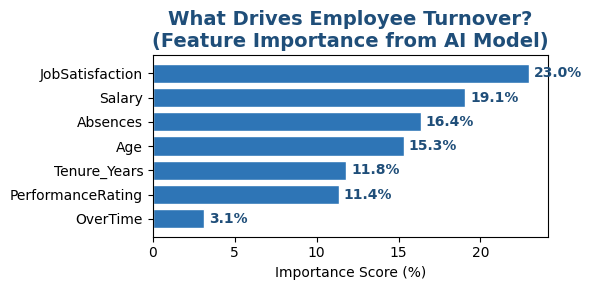


💡 Top driver of turnover: JobSatisfaction


In [20]:
# Create a DataFrame to store feature importance scores
importance_df = pd.DataFrame({
    'Feature': features, # List of features used in the model
    'Importance': model.feature_importances_ # Importance score for each feature from the trained model
}).sort_values('Importance', ascending=True) # Sort by importance in ascending order

# Create a horizontal bar plot for feature importance
plt.figure(figsize=(6, 3))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'] * 100,
                color=LIGHT_BLUE, edgecolor='white') # Bars representing importance scores
# Set the title of the plot
plt.title('What Drives Employee Turnover?\n(Feature Importance from AI Model)',
          fontsize=14, fontweight='bold', color=BLUE)
# Set the x-axis label
plt.xlabel('Importance Score (%)')
# Add percentage labels to each bar
for bar, val in zip(bars, importance_df['Importance']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontweight='bold', color=BLUE)
# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Identify and print the top driving factor for turnover
top_factor = importance_df.iloc[-1]['Feature'] # Get the feature with the highest importance
print(f'\n💡 Top driver of turnover: {top_factor}')

## Step 7 — Identify At-Risk Employees

          ⚠️  AT-RISK EMPLOYEES — IMMEDIATE ATTENTION REQUIRED
EmployeeID Department            JobTitle  Tenure_Years  JobSatisfaction  Absences  Churn_Probability
   EMP0165 Operations Process Coordinator             4                1        12               72.0

  1 employees identified as high churn risk (>60% probability)


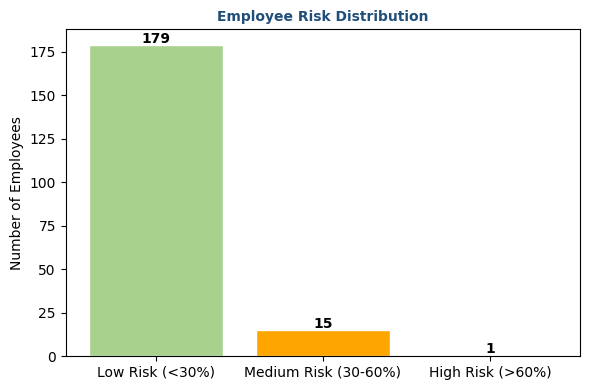

In [26]:
# Predict churn probabilities for all employees
# probs[:, 1] gets the probability of the employee leaving (class 1)
probs = model.predict_proba(X)[:, 1]
# Create a copy of the original DataFrame to avoid modifying it directly
df_risk = df.copy()
# Add a new column 'Churn_Probability' with probabilities rounded to one decimal place
df_risk['Churn_Probability'] = (probs * 100).round(1)

# Identify 'at-risk' employees:
# - Those who are currently 'Active'
# - Have a churn probability greater than 60%
# Sort them by churn probability in descending order and select the top 10
at_risk = df_risk[
    (df_risk['EmploymentStatus'] == 'Active') &
    (df_risk['Churn_Probability'] > 60)
].sort_values('Churn_Probability', ascending=False).head(10)

# Print a header for the 'At-Risk Employees' section
print('=' * 70)
print('          ⚠️  AT-RISK EMPLOYEES — IMMEDIATE ATTENTION REQUIRED')
print('=' * 70)
# Display key information for at-risk employees
print(at_risk[['EmployeeID', 'Department', 'JobTitle', 'Tenure_Years',
               'JobSatisfaction', 'Absences', 'Churn_Probability']].to_string(index=False))
# Print the count of identified at-risk employees
print(f'\n  {len(at_risk)} employees identified as high churn risk (>60% probability)')

# Visualise risk distribution
plt.figure(figsize=(6, 4))
# Filter for active employees only for risk distribution analysis
active_df = df_risk[df_risk['EmploymentStatus'] == 'Active']
# Categorize churn probabilities into risk bins (Low, Medium, High)
risk_counts = pd.cut(active_df['Churn_Probability'],
                     bins=[0, 30, 60, 100],
                     labels=['Low Risk (<30%)', 'Medium Risk (30-60%)', 'High Risk (>60%)']).value_counts()
# Define colors for the risk categories
colors_risk = [GREEN, 'orange', RED]
# Create a bar chart for employee risk distribution
plt.bar(risk_counts.index, risk_counts.values, color=colors_risk, edgecolor='white')
# Set the title of the plot
plt.title('Employee Risk Distribution', fontsize=10, fontweight='bold', color=BLUE)
# Set the y-axis label
plt.ylabel('Number of Employees')
# Add count labels on top of each bar
for i, (idx, val) in enumerate(risk_counts.items()):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold', fontsize=10)
# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()

## Step 8 — Key Recommendations

In [17]:
# Print header for recommendations section
print('=' * 60)
print('        💡 PEOPLEIQ — KEY RECOMMENDATIONS')
print('=' * 60)

# Identify departments with low average job satisfaction (below 5.5/10)
low_sat_depts = dept_stats[dept_stats['Avg_Satisfaction'] < 5.5]['Department'].tolist()
# Identify departments with high turnover rates (above 35%)
high_turnover_depts = dept_stats[dept_stats['Turnover_Rate'] > 35]['Department'].tolist()

# Print key recommendations based on the analysis
print(f'''
1. IMPROVE JOB SATISFACTION
   Job satisfaction is the #1 predictor of turnover.
   Departments below 5.5/10: {', '.join(low_sat_depts) if low_sat_depts else 'None'}
   → Conduct stay interviews and address concerns immediately.

2. MONITOR ABSENTEEISM
   High absences strongly correlate with turnover risk.
   → Employees with 15+ absences need proactive check-ins.

3. FOCUS ON HIGH-TURNOVER DEPARTMENTS
   Departments above 35% turnover: {', '.join(high_turnover_depts) if high_turnover_depts else 'None'}
   → Review workload, management practices and compensation.

4. REVIEW OVERTIME POLICY
   Employees working overtime are significantly more likely to leave.
   → Redistribute workload and monitor burnout signals.

5. INTERVENE WITH AT-RISK EMPLOYEES
   {len(at_risk)} active employees have >60% churn probability.
   → Schedule 1-on-1 meetings and create retention plans.
''')
# Print footer
print('=' * 60)
print('  Built by Myra Owoo | github.com/mowoo-987/PeopleIQ')
print('=' * 60)

        💡 PEOPLEIQ — KEY RECOMMENDATIONS

1. IMPROVE JOB SATISFACTION
   Job satisfaction is the #1 predictor of turnover.
   Departments below 5.5/10: Customer Service, Engineering, Finance, IT, Marketing
   → Conduct stay interviews and address concerns immediately.

2. MONITOR ABSENTEEISM
   High absences strongly correlate with turnover risk.
   → Employees with 15+ absences need proactive check-ins.

3. FOCUS ON HIGH-TURNOVER DEPARTMENTS
   Departments above 35% turnover: Customer Service, Finance, IT
   → Review workload, management practices and compensation.

4. REVIEW OVERTIME POLICY
   Employees working overtime are significantly more likely to leave.
   → Redistribute workload and monitor burnout signals.

5. INTERVENE WITH AT-RISK EMPLOYEES
   1 active employees have >60% churn probability.
   → Schedule 1-on-1 meetings and create retention plans.

  Built by Myra Owoo | github.com/mowoo-987/PeopleIQ
